In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    recall_score, confusion_matrix, 
    precision_score, f1_score, 
    accuracy_score, classification_report,
    roc_auc_score, roc_curve)

# 1. Load cleaned data

In [2]:
# load the cleaned version of our data
df = pd.read_csv("../data/processed/cleaned.csv")
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,No,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,No,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,No,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,No,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,No,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [3]:
df.shape

(7043, 16)

# 2. Train/test split

In [4]:
# split the data into train and test splits

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Since the numerical features are distributed over different value ranges, I will use standard scalar to scale them down to the same range.

# 3. Minimal preprocessing pipeline

In [5]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test  = y_test.map({"No": 0, "Yes": 1})

In [6]:
num_cols = ["tenure", "MonthlyCharges"]
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PaperlessBilling"]
nominal_cols = ["InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod"]

# binary map before implementing column transformer
for col in binary_cols:
    X_train[col] = X_train[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})
    X_test[col] = X_test[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_cols)
], remainder="passthrough")
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# 4. Dummy baseline

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.7345635202271115

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC AUC":   roc_auc_score(y_test, y_prob),
    }

    print(f"\n{'='*40}")
    print(f"  {model_name} Results")
    print(f"{'='*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Evaluation", fontsize=14)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False,)
    axes[0].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['ROC AUC']:.4f}")
    axes[1].plot([0,1], [0,1], '--', color='gray', alpha=0.5, label='Chance')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics


  Dummy model Results
  Accuracy    : 0.7346
  Precision   : 0.0000
  Recall      : 0.0000
  F1 Score    : 0.0000
  ROC AUC     : 0.5000


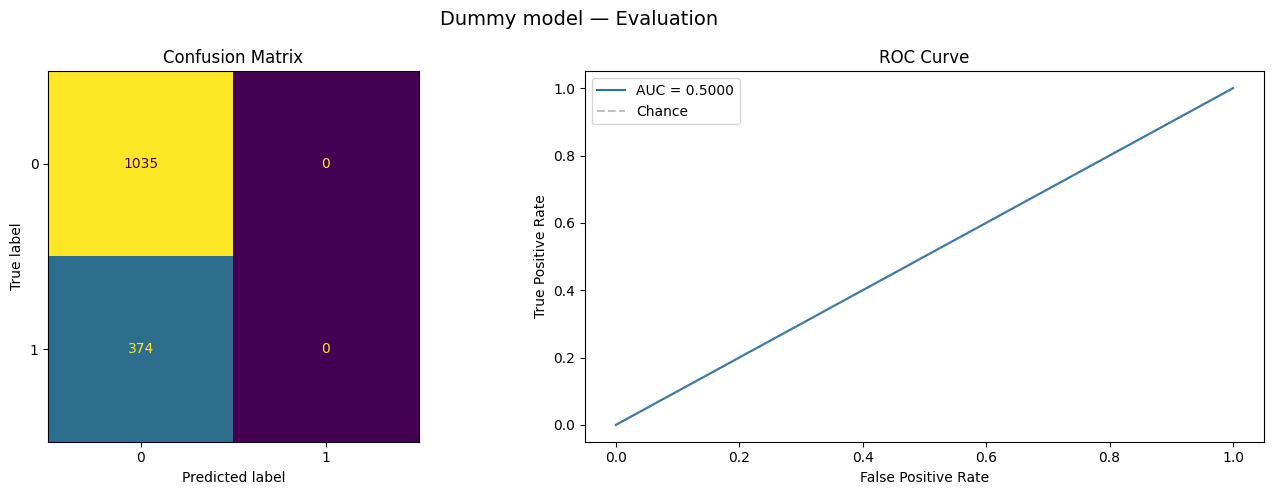

In [9]:
dummy_results = evaluate_model(dummy, X_train, X_test, y_train, y_test, model_name="Dummy model")

- the `score` of the dummy model is ~73.5% and it's only predict the most frequent label which is "No"

- also, it's obvious that precision, recall and f1 score are 0 because the model only predict the negative class, so the `True Positive` always 0

### Compare dummy with logistic regression


  Logistic regression model Results
  Accuracy    : 0.7977
  Precision   : 0.6422
  Recall      : 0.5374
  F1 Score    : 0.5852
  ROC AUC     : 0.8383


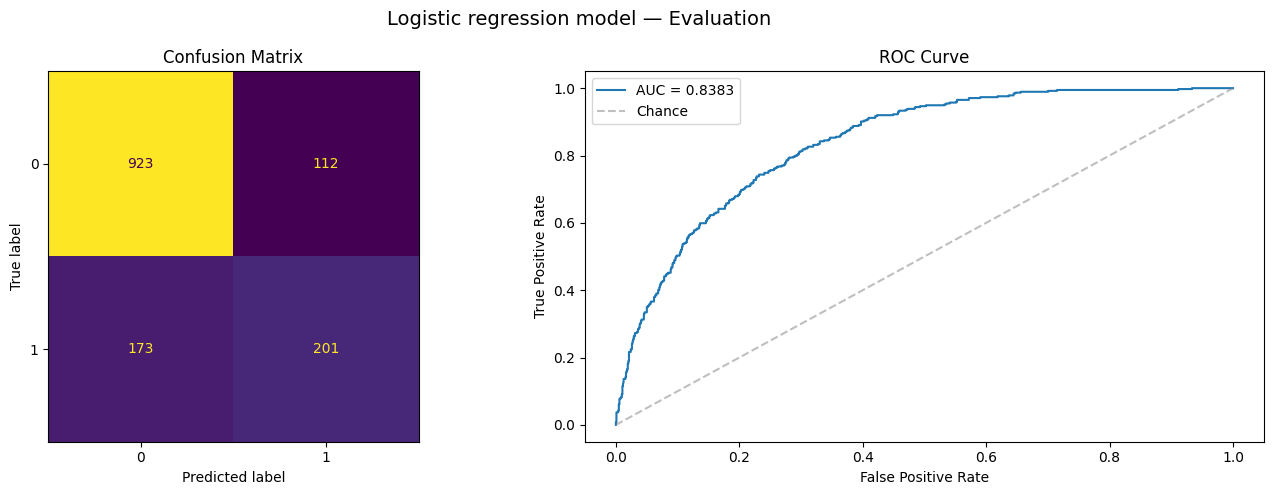

In [10]:
logreg_results  = evaluate_model(pipe, X_train, X_test, y_train, y_test, model_name="Logistic regression model")

<div align="center">

| Metric | Dummy | Logreg | Delta |
|:-------|:-----:|:------:|:-----:|
| Accuracy  | 0.7346 | 0.7977 | +0.0631 |
| Precision | 0.0000 | **0.6422** | — |
| Recall    | 0.0000 | **0.5374** | — |
| F1 Score  | 0.0000 | **0.5852** | — |
| ROC AUC   | 0.5000 | **0.8383** | +0.3383 |

</div>

<details>
<summary><b>Why False Negative matters most</b></summary>

False Negative is about **missing a churner** and actually this will cost the company from £300 – £1000 because, they lost their entire customer life time value. and to capture this phenomena, we have to look at **recall** in order to optimize this number and decrease it as much as we can.

on the other hand, False Positive, is about **False alarm on loyal customer** and it detected to left so we will send him a a special discount/incentive to stay, this will cost us around £10 – £50 (The cost of the unnecessary promo).

</details>